# Delta Learning for Adsorption Energies

This notebook builds delta-learning models to map `OC25` and `UMA` predictions to `RPBE` accuracy on the `adsorption energies` sheet from `energies_comparison.xlsx`.

It includes data loading, cross-validated model evaluation, and corrected parity plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 7),
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'lines.linewidth': 2.2,
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'font.size': 22,
})

In [2]:
DATA_PATH = 'energies_comparison.xlsx'
SHEET = 'adsorption energies'
GROUP_COL = 'System'

adsorption_df = pd.read_excel(DATA_PATH, sheet_name=SHEET)


def pick_col(df, candidates):
    normalized = {c.lower().replace(' ', '').replace('(ev)', '').strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '').replace('(ev)', '').strip()
        if key in normalized:
            return normalized[key]
    raise KeyError(f'Could not find any of columns: {candidates}. Available: {list(df.columns)}')


RPBE_COL = pick_col(adsorption_df, ['RPBE', 'RPBE (eV)'])
OC25_COL = pick_col(adsorption_df, ['OC25', 'OC25 (eV)'])
UMA_COL = pick_col(adsorption_df, ['UMA', 'UMA (eV)'])
BASELINES = [OC25_COL, UMA_COL]

adsorption_df['delta_oc25'] = adsorption_df[RPBE_COL] - adsorption_df[OC25_COL]
adsorption_df['delta_uma'] = adsorption_df[RPBE_COL] - adsorption_df[UMA_COL]

print('Resolved columns:', {'RPBE': RPBE_COL, 'OC25': OC25_COL, 'UMA': UMA_COL})
print(f'Loaded {SHEET!r}: {adsorption_df.shape}')
display(adsorption_df.head())

Resolved columns: {'RPBE': 'RPBE (eV)', 'OC25': 'OC25 (eV)', 'UMA': 'UMA (eV)'}
Loaded 'adsorption energies': (35, 8)


,System,Molecules,RPBE (eV),PBE (eV),OC25 (eV),UMA (eV),delta_oc25,delta_uma
0,2_hydroxypyridine,2_hydroxypyridine,-2.105141,-3.324810,-1.699037,-0.005437,-0.406105,-2.099704
1,benzaldehyde,benzaldehyde,-2.573438,-4.051754,-1.961648,-0.217101,-0.611790,-2.356338
2,benzaldehyde_2_hydroxypyridine,benzaldehyde + 2_hydroxypyridine,-4.937378,-7.582819,-3.971095,-0.470062,-0.966283,-4.467316
3,benzaldehyde_benzaldehyde,benzaldehyde + benzaldehyde,-5.121447,-8.138025,-4.001681,-0.425794,-1.119766,-4.695653
4,benzaldehyde_benzene,benzaldehyde + benzene,-4.856082,-7.548102,-3.733782,-0.535237,-1.122299,-4.320845


In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def get_splitter(df, group_col='System', n_splits=5, seed=42):
    """
    Prefer GroupKFold by system if possible. Fallback to standard KFold.
    """
    n = len(df)
    k = max(2, min(n_splits, n))

    if group_col in df.columns:
        groups = df[group_col].astype(str)
        unique_groups = groups.nunique()
        if unique_groups >= 2:
            k_group = min(k, unique_groups)
            return GroupKFold(n_splits=k_group), groups.values

    return KFold(n_splits=k, shuffle=True, random_state=seed), None


def cross_val_predict_custom(df, x_col, y_col, pred_fn, splitter, groups=None):
    """
    Build out-of-fold predictions using a provided train->predict function.
    """
    X = df[[x_col]].to_numpy().reshape(-1)
    y = df[y_col].to_numpy().reshape(-1)
    preds = np.full_like(y, fill_value=np.nan, dtype=float)

    if groups is None:
        split_iter = splitter.split(X)
    else:
        split_iter = splitter.split(X, y, groups)

    for tr_idx, te_idx in split_iter:
        y_hat = pred_fn(X[tr_idx], y[tr_idx], X[te_idx])
        preds[te_idx] = y_hat

    return y, preds


def evaluate_one_baseline(df, baseline_col, target_col='RPBE', group_col='System'):
    cols = [target_col, baseline_col]
    if group_col in df.columns:
        cols.append(group_col)

    tmp = df[cols].dropna().copy()
    if len(tmp) < 3:
        raise ValueError(f'Not enough paired rows for {baseline_col} -> {target_col}.')

    splitter, groups = get_splitter(tmp, group_col=group_col, n_splits=5)

    def pred_raw(X_tr, y_tr, X_te):
        return X_te

    def pred_constant_delta(X_tr, y_tr, X_te):
        delta_mean = np.mean(y_tr - X_tr)
        return X_te + delta_mean

    def pred_linear_cal(X_tr, y_tr, X_te):
        model = LinearRegression()
        model.fit(X_tr.reshape(-1, 1), y_tr)
        return model.predict(X_te.reshape(-1, 1))

    model_fns = {
        'raw_baseline': pred_raw,
        'constant_bias_corrected': pred_constant_delta,
        'linear_calibrated': pred_linear_cal,
    }

    rows = []
    oof_predictions = {}
    for model_name, fn in model_fns.items():
        y_true, y_pred = cross_val_predict_custom(
            tmp,
            x_col=baseline_col,
            y_col=target_col,
            pred_fn=fn,
            splitter=splitter,
            groups=groups,
        )
        rows.append({
            'baseline': baseline_col,
            'model': model_name,
            'n_rows': len(tmp),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': rmse(y_true, y_pred),
        })
        oof_predictions[model_name] = (y_true, y_pred)

    metrics_df = pd.DataFrame(rows).sort_values(['baseline', 'RMSE']).reset_index(drop=True)
    return metrics_df, oof_predictions


def parity_plot(y_true, y_pred, title):
    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred, alpha=0.8, s=48, color='#1f77b4')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    pad = 0.03 * (mx - mn if mx > mn else 1)
    ax.plot([mn - pad, mx + pad], [mn - pad, mx + pad], 'k--', lw=1.6)
    ax.set_xlabel('True RPBE adsorption energy')
    ax.set_ylabel('Predicted RPBE adsorption energy')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [4]:
all_metrics = []
all_oof = {}
all_pred_rows = []

for baseline in BASELINES:
    mdf, oof = evaluate_one_baseline(
        adsorption_df,
        baseline_col=baseline,
        target_col=RPBE_COL,
        group_col=GROUP_COL,
    )
    all_metrics.append(mdf)
    all_oof[baseline] = oof

    tmp_cols = [RPBE_COL, baseline] + ([GROUP_COL] if GROUP_COL in adsorption_df.columns else [])
    tmp = adsorption_df[tmp_cols].dropna().copy().reset_index(drop=True)
    for model_name, (y_true, y_pred) in oof.items():
        out = tmp.copy()
        out['baseline'] = baseline
        out['model'] = model_name
        out['RPBE_true'] = y_true
        out['RPBE_pred'] = y_pred
        out['delta_used'] = out[RPBE_COL] - out[baseline]
        out['residual_after_correction'] = out['RPBE_true'] - out['RPBE_pred']
        all_pred_rows.append(out)

results_df = pd.concat(all_metrics, ignore_index=True).sort_values(['baseline', 'RMSE']).reset_index(drop=True)
predictions_df = pd.concat(all_pred_rows, ignore_index=True)

results_df.to_csv('delta_learning_metrics.csv', index=False)
predictions_df.to_csv('delta_learning_predictions_oof.csv', index=False)

delta_export_cols = ([GROUP_COL] if GROUP_COL in adsorption_df.columns else []) + [RPBE_COL, OC25_COL, UMA_COL, 'delta_oc25', 'delta_uma']
adsorption_df[delta_export_cols].to_csv('delta_values_from_adsorption_sheet.csv', index=False)

display(results_df)
display(predictions_df.head())
print('Saved: delta_learning_metrics.csv')
print('Saved: delta_learning_predictions_oof.csv')
print('Saved: delta_values_from_adsorption_sheet.csv')

,baseline,model,n_rows,MAE,RMSE
0,OC25 (eV),linear_calibrated,35,0.059743,0.073589
1,OC25 (eV),constant_bias_corrected,35,0.272112,0.299864
2,OC25 (eV),raw_baseline,35,0.793621,0.847367
3,UMA (eV),linear_calibrated,35,0.571516,0.749699
4,UMA (eV),constant_bias_corrected,35,1.190754,1.255369
5,UMA (eV),raw_baseline,35,3.271226,3.499528


,RPBE (eV),OC25 (eV),System,baseline,model,RPBE_true,RPBE_pred,delta_used,residual_after_correction,UMA (eV)
0,-2.105141,-1.699037,2_hydroxypyridine,OC25 (eV),raw_baseline,-2.105141,-1.699037,-0.406105,-0.406105,NaN
1,-2.573438,-1.961648,benzaldehyde,OC25 (eV),raw_baseline,-2.573438,-1.961648,-0.611790,-0.611790,NaN
2,-4.937378,-3.971095,benzaldehyde_2_hydroxypyridine,OC25 (eV),raw_baseline,-4.937378,-3.971095,-0.966283,-0.966283,NaN
3,-5.121447,-4.001681,benzaldehyde_benzaldehyde,OC25 (eV),raw_baseline,-5.121447,-4.001681,-1.119766,-1.119766,NaN
4,-4.856082,-3.733782,benzaldehyde_benzene,OC25 (eV),raw_baseline,-4.856082,-3.733782,-1.122299,-1.122299,NaN


Saved: delta_learning_metrics.csv
Saved: delta_learning_predictions_oof.csv
Saved: delta_values_from_adsorption_sheet.csv


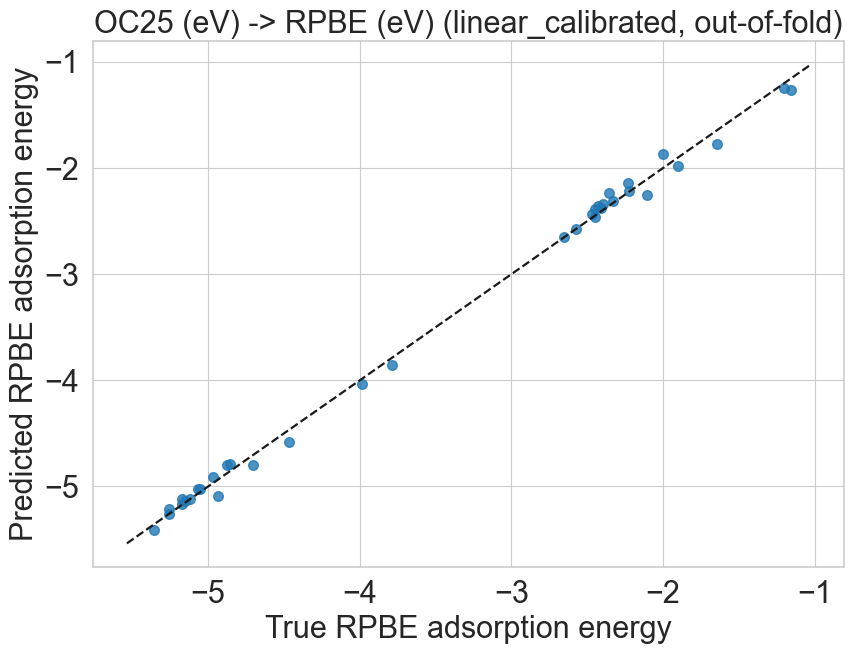

OC25 (eV): best=linear_calibrated | MAE=0.0597 | RMSE=0.0736


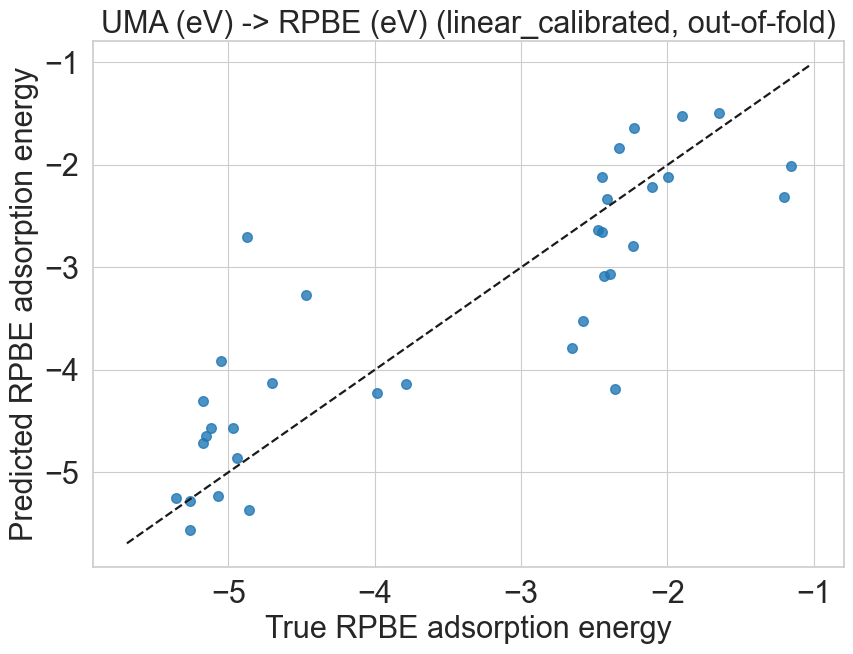

UMA (eV): best=linear_calibrated | MAE=0.5715 | RMSE=0.7497


In [5]:
# Plot one parity chart per baseline for the best-performing model
for baseline in BASELINES:
    subset = results_df[results_df['baseline'] == baseline].sort_values('RMSE')
    best_model = subset.iloc[0]['model']
    y_true, y_pred = all_oof[baseline][best_model]
    parity_plot(
        y_true,
        y_pred,
        title=f'{baseline} -> {RPBE_COL} ({best_model}, out-of-fold)',
    )
    print(f'{baseline}: best={best_model} | MAE={mean_absolute_error(y_true, y_pred):.4f} | RMSE={rmse(y_true, y_pred):.4f}')